#### Mount Drive & Directory Setup


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
print('  Google Drive mounted')

import os

BASE     = '/content/drive/MyDrive/MedSSL_Research'
DATA_DIR = f'{BASE}/dataset/raw'

if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f'DATA_DIR not found: {DATA_DIR}\n'
        'Upload your images to Google Drive at '
        'MyDrive/MedSSL_Research/dataset/raw/ first.'
    )
print(f'  DATA_DIR verified: {DATA_DIR}')

Mounted at /content/drive
  Google Drive mounted
  DATA_DIR verified: /content/drive/MyDrive/MedSSL_Research/dataset/raw


In [2]:
DIRS = [
    f'{BASE}/dataset/processed',
    f'{BASE}/splits',
    f'{BASE}/checkpoints/supervised',
    f'{BASE}/checkpoints/ssl',
    f'{BASE}/checkpoints/finetuned',
    f'{BASE}/results',
    f'{BASE}/figures',
    f'{BASE}/logs',
]
for d in DIRS:
    os.makedirs(d, exist_ok=True)
print('  Output directories ready')

CONFIG = {
    'BASE'              : BASE,
    'DATA_DIR'          : DATA_DIR,
    'PROCESSED_DIR'     : f'{BASE}/dataset/processed',
    'SPLITS_DIR'        : f'{BASE}/splits',
    'FIGURES_DIR'       : f'{BASE}/figures',
    'LOGS_DIR'          : f'{BASE}/logs',
    'SPLIT_SEED'        : 42,
    'TEST_SIZE'         : 0.20,
    'VAL_SIZE_INNER'    : 0.125,
    'SUBSET_10PCT'      : 0.10,
    'SUBSET_20PCT'      : 0.20,
    'RESIZE_TO'         : 224,
    'JPEG_QUALITY'      : 95,
    'RESOLUTION_SAMPLE' : 1000,
    'VISUAL_GRID_N'     : 8,
    'IMBALANCE_THRESH'  : 3.0,
    'FIGURE_DPI'        : 300,
    'EXPECTED_CLASSES'  : 6,
    'USE_CLASS_WEIGHTS' : False,
    'NUM_CLASSES'       : None,
    'CLASS_NAMES'       : None,
}

print()
print('=' * 55)
print('  CELL 0 COMPLETE')
print(f'  BASE = {BASE}')
print('=' * 55)

  Output directories ready

  CELL 0 COMPLETE
  BASE = /content/drive/MyDrive/MedSSL_Research


#### Build Master DataFrame   

In [3]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 150
from tqdm.notebook import tqdm

VALID_EXT = {'.jpg', '.jpeg', '.png'}

def scan_dataset(data_dir):
    class_dirs = sorted([
        d for d in os.listdir(data_dir)
        if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')
    ])
    class_to_idx = {name: idx for idx, name in enumerate(class_dirs)}
    records = []
    for cls in tqdm(class_dirs, desc='Scanning classes'):
        cls_dir = os.path.join(data_dir, cls)
        for root, _, files in os.walk(cls_dir):
            for fname in files:
                if os.path.splitext(fname)[1].lower() in VALID_EXT:
                    records.append({
                        'image_path' : os.path.join(root, fname),
                        'label_name' : cls,
                        'label_idx'  : class_to_idx[cls],
                    })
    return pd.DataFrame(records), class_dirs, class_to_idx

df, CLASS_NAMES, CLASS_TO_IDX = scan_dataset(CONFIG['DATA_DIR'])
NUM_CLASSES = len(CLASS_NAMES)

if NUM_CLASSES != CONFIG['EXPECTED_CLASSES']:
    raise ValueError(
        f'Expected {CONFIG["EXPECTED_CLASSES"]} classes, found {NUM_CLASSES}: {CLASS_NAMES}'
    )

CONFIG['NUM_CLASSES'] = NUM_CLASSES
CONFIG['CLASS_NAMES'] = CLASS_NAMES

class_counts = df['label_name'].value_counts().sort_index()
print(f'Total images : {len(df):,}')
print(f'Classes ({NUM_CLASSES}) : {CLASS_NAMES}')
print()
for cls, cnt in class_counts.items():
    print(f'  {cls:<30} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)')


Scanning classes:   0%|          | 0/6 [00:00<?, ?it/s]

Total images : 18,036
Classes (6) : ['covid-19', 'emphysema', 'normal', 'pneumonia-bacterial', 'pneumonia-viral', 'tuberculosis']

  covid-19                        3,017  (16.7%)
  emphysema                       2,550  (14.1%)
  normal                          3,271  (18.1%)
  pneumonia-bacterial             3,000  (16.6%)
  pneumonia-viral                 3,013  (16.7%)
  tuberculosis                    3,185  (17.7%)


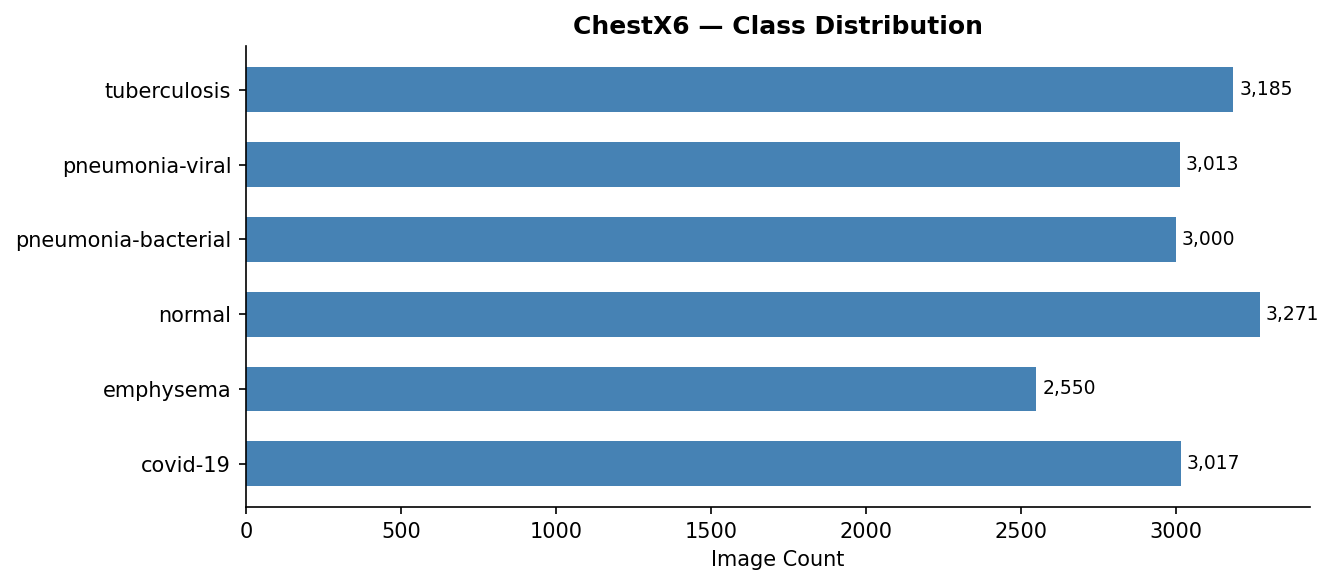

Saved: /content/drive/MyDrive/MedSSL_Research/figures/class_distribution.png

  CELL 1 COMPLETE — 18,036 images, 6 classes


In [4]:
# Bar plot of Class Distributions

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(class_counts.index, class_counts.values, color='steelblue', height=0.6)
for bar, val in zip(bars, class_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_xlabel('Image Count')
ax.set_title('ChestX6 — Class Distribution', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path = f'{CONFIG["FIGURES_DIR"]}/class_distribution.png'
plt.savefig(fig_path, dpi=CONFIG['FIGURE_DPI'], bbox_inches='tight')
plt.show()
print(f'Saved: {fig_path}')

print()
print('=' * 55)
print(f'  CELL 1 COMPLETE — {len(df):,} images, {NUM_CLASSES} classes')
print('=' * 55)

#### Corrupted File Scan  

In [5]:
# Scan if there's currupted file

from PIL import Image
from tqdm.notebook import tqdm
import os

def scan_corrupted(dataframe):
    corrupted = []
    for path in tqdm(dataframe['image_path'], desc='Verifying images', mininterval=2.0):
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception:
            corrupted.append(path)
    return corrupted

corrupted_paths = scan_corrupted(df)
n_corrupted = len(corrupted_paths)

if n_corrupted > 0:
    df = df[~df['image_path'].isin(corrupted_paths)].reset_index(drop=True)
    print(f'[WARN] {n_corrupted} corrupted files removed.')
else:
    print('No corrupted files found.')

corrupted_log = f'{CONFIG["LOGS_DIR"]}/corrupted_files.txt'
with open(corrupted_log, 'w') as f:
    f.write('\n'.join(corrupted_paths) if corrupted_paths else '# No corrupted files.\n')
print(f'Log saved: {corrupted_log}')

print()
print('=' * 55)
print(f'  CELL 2 COMPLETE  |  Corrupted removed: {n_corrupted}  |  Remaining: {len(df):,}')
print('=' * 55)

Verifying images:   0%|          | 0/18036 [00:00<?, ?it/s]

No corrupted files found.
Log saved: /content/drive/MyDrive/MedSSL_Research/logs/corrupted_files.txt

  CELL 2 COMPLETE  |  Corrupted removed: 0  |  Remaining: 18,036


#### Deep Dataset Audit

In [6]:
import random, hashlib
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.notebook import tqdm

random.seed(CONFIG['SPLIT_SEED'])
np.random.seed(CONFIG['SPLIT_SEED'])

3a. Class Distribution ...
  Imbalance ratio: 1.28 — class weights not required


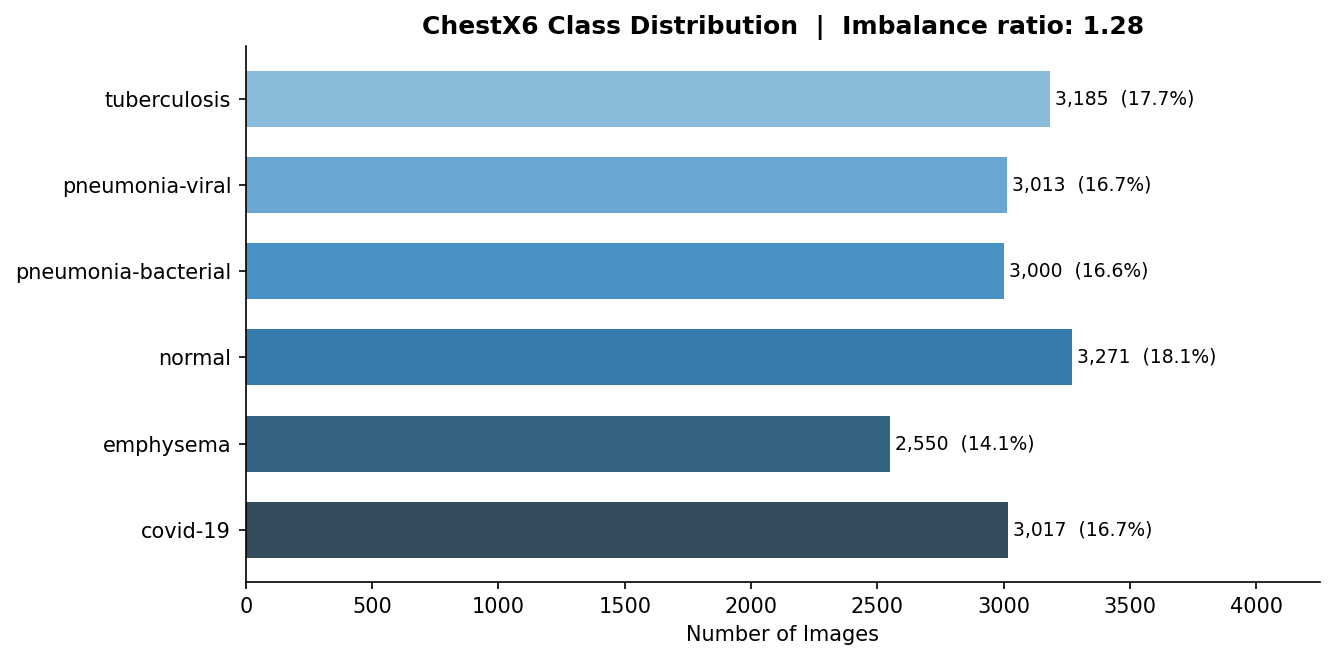

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/class_distribution.png


In [7]:
# ── 3a. Class Distribution ────────────────────────────────

print('3a. Class Distribution ...')
class_counts = df['label_name'].value_counts().sort_index()
imbalance_ratio = class_counts.max() / class_counts.min()

if imbalance_ratio > CONFIG['IMBALANCE_THRESH']:
    CONFIG['USE_CLASS_WEIGHTS'] = True
    print(f'  WARNING: imbalance ratio={imbalance_ratio:.2f} — USE_CLASS_WEIGHTS=True')
else:
    print(f'  Imbalance ratio: {imbalance_ratio:.2f} — class weights not required')

colors = sns.color_palette('Blues_d', n_colors=len(class_counts))[::-1]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.barh(class_counts.index, class_counts.values, color=colors, height=0.65)
for bar, val in zip(bars, class_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Number of Images')
ax.set_title(f'ChestX6 Class Distribution  |  Imbalance ratio: {imbalance_ratio:.2f}', fontweight='bold')
ax.set_xlim(0, class_counts.max() * 1.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig_path_3a = f'{CONFIG["FIGURES_DIR"]}/class_distribution.png'
plt.savefig(fig_path_3a, dpi=CONFIG['FIGURE_DPI'], bbox_inches='tight')
plt.show()
print(f'  Saved: {fig_path_3a}')


3b. Resolution Distribution ...


Reading resolutions:   0%|          | 0/1000 [00:00<?, ?it/s]

  Width  — mean:224  std:0  min:224  max:224
  Height — mean:224  std:0  min:224  max:224
  All images will be resized to 224x224


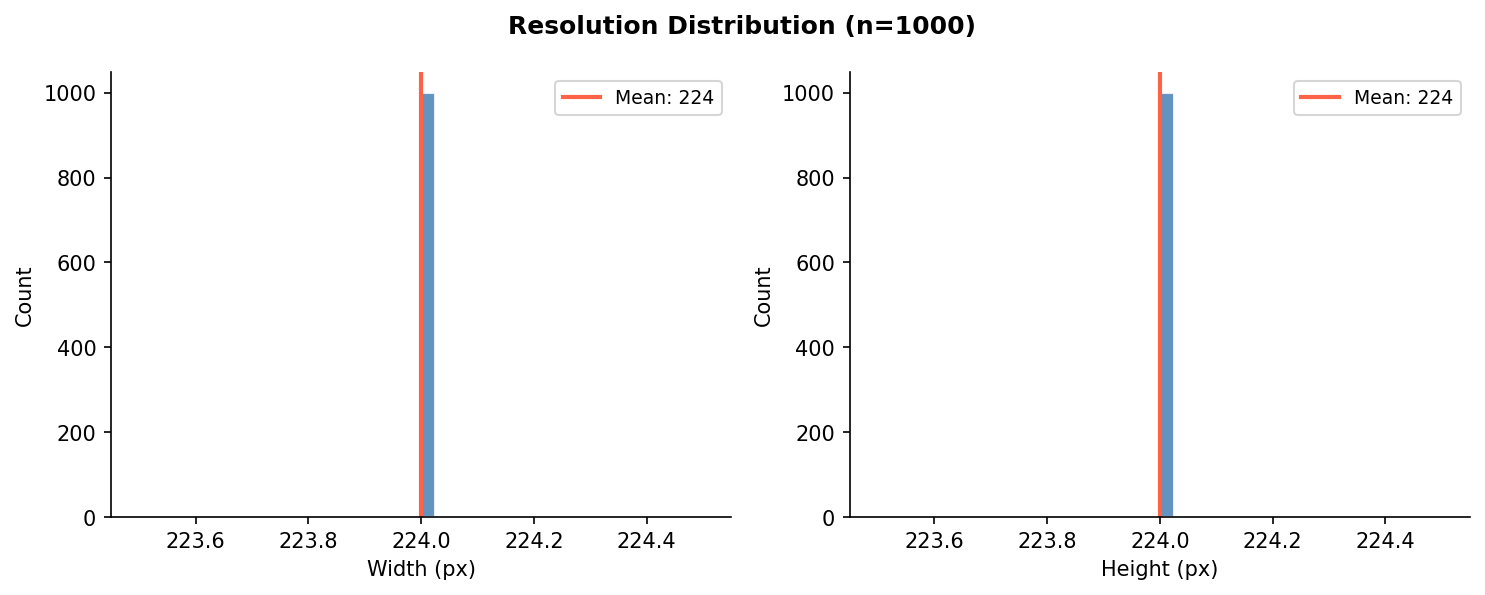

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/resolution_distribution.png


In [8]:
# ── 3b. Resolution Distribution ──────────────────────────

print('\n3b. Resolution Distribution ...')
sample_n = min(CONFIG['RESOLUTION_SAMPLE'], len(df))
sample_df = df.sample(n=sample_n, random_state=CONFIG['SPLIT_SEED'])
widths, heights = [], []
for path in tqdm(sample_df['image_path'], desc='Reading resolutions', mininterval=2.0):
    try:
        with Image.open(path) as img:
            w, h = img.size
        widths.append(w); heights.append(h)
    except Exception:
        pass

widths = np.array(widths); heights = np.array(heights)
print(f'  Width  — mean:{widths.mean():.0f}  std:{widths.std():.0f}  min:{widths.min()}  max:{widths.max()}')
print(f'  Height — mean:{heights.mean():.0f}  std:{heights.std():.0f}  min:{heights.min()}  max:{heights.max()}')
print(f'  All images will be resized to {CONFIG["RESIZE_TO"]}x{CONFIG["RESIZE_TO"]}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, data, label in zip(axes, [widths, heights], ['Width (px)', 'Height (px)']):
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='tomato', linewidth=2, label=f'Mean: {data.mean():.0f}')
    ax.set_xlabel(label); ax.set_ylabel('Count'); ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
fig.suptitle(f'Resolution Distribution (n={sample_n})', fontweight='bold')
plt.tight_layout()
fig_path_3b = f'{CONFIG["FIGURES_DIR"]}/resolution_distribution.png'
plt.savefig(fig_path_3b, dpi=CONFIG['FIGURE_DPI'], bbox_inches='tight')
plt.show()
print(f'  Saved: {fig_path_3b}')


3c. Visual Inspection Grid ...


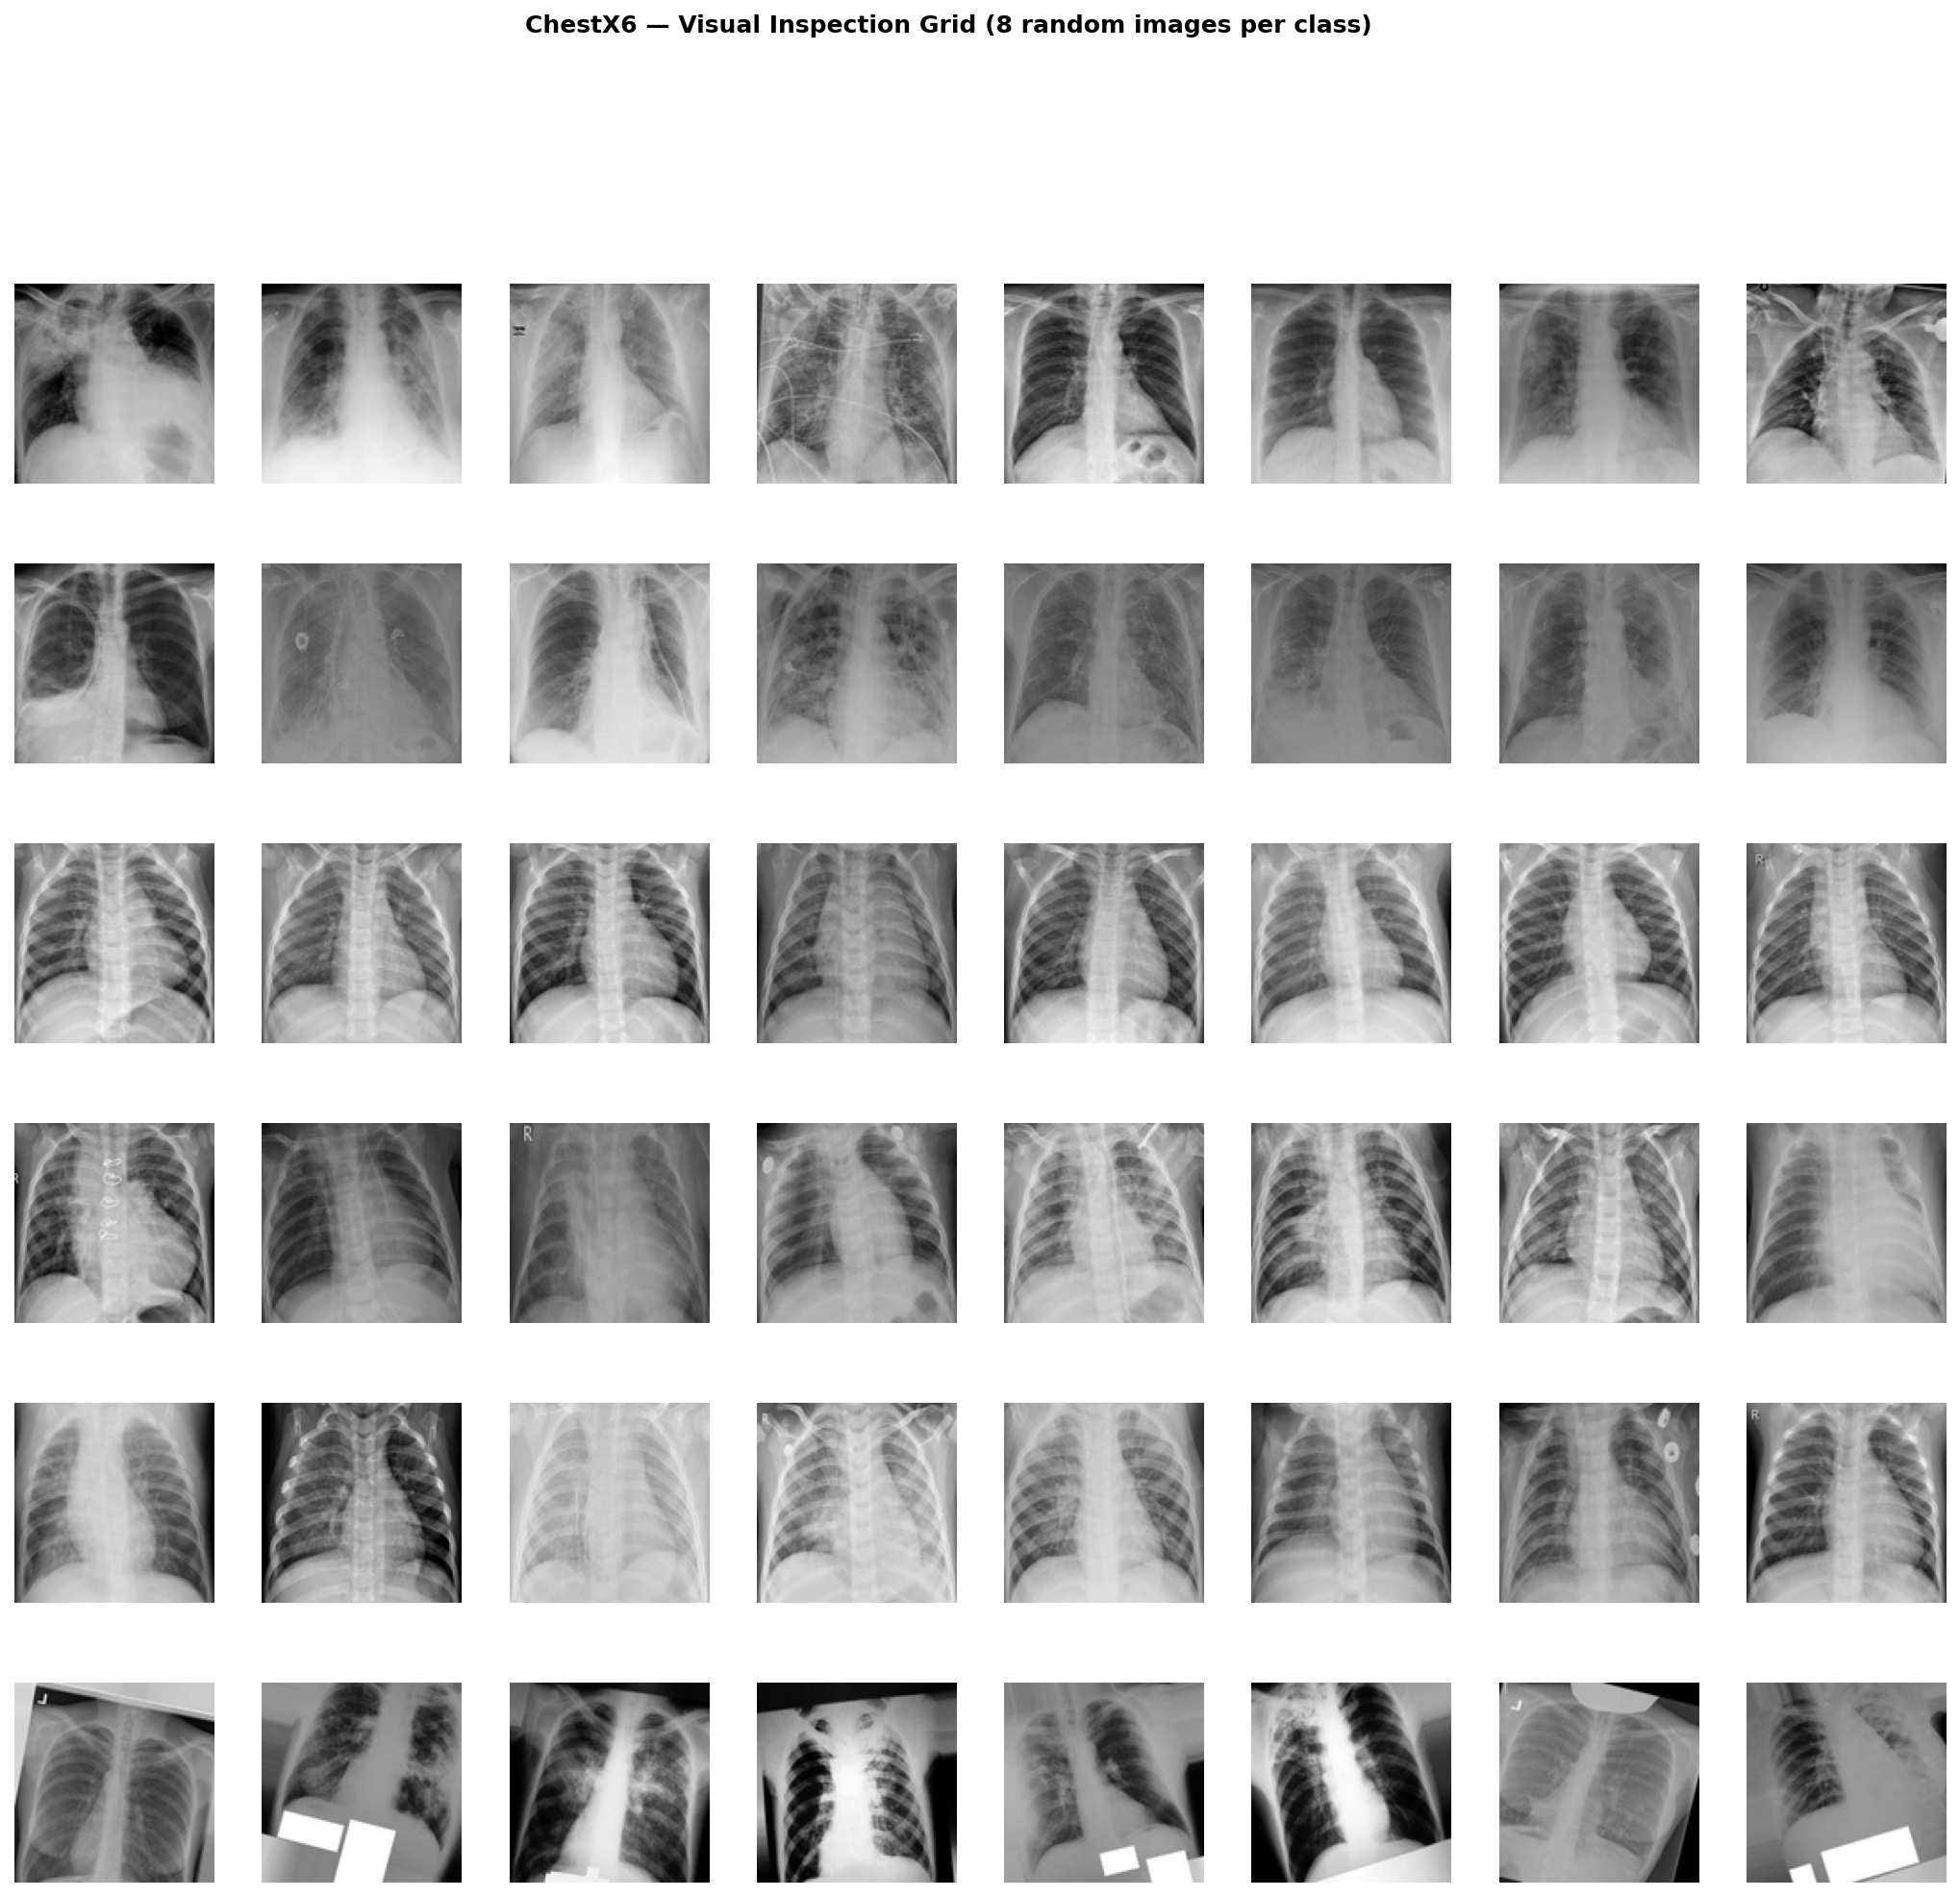

  Saved: /content/drive/MyDrive/MedSSL_Research/figures/visual_inspection_grid.png


In [9]:
# ── 3c. Visual Inspection Grid ───────────────────────────

print('\n3c. Visual Inspection Grid ...')
N_PER_CLASS = CONFIG['VISUAL_GRID_N']
n_classes   = len(CLASS_NAMES)

fig = plt.figure(figsize=(N_PER_CLASS * 2.2, n_classes * 2.4))
gs  = gridspec.GridSpec(n_classes, N_PER_CLASS, hspace=0.4, wspace=0.05)

for row_idx, cls in enumerate(CLASS_NAMES):
    cls_paths = df[df['label_name'] == cls]['image_path'].tolist()
    samples   = random.sample(cls_paths, min(N_PER_CLASS, len(cls_paths)))
    for col_idx, path in enumerate(samples):
        ax = fig.add_subplot(gs[row_idx, col_idx])
        try:
            img = Image.open(path).convert('RGB').resize((112, 112), Image.LANCZOS)
            ax.imshow(img)
        except Exception:
            ax.imshow(np.zeros((112, 112, 3), dtype=np.uint8))
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=8, rotation=0,
                          labelpad=65, va='center', fontweight='bold')

fig.suptitle('ChestX6 — Visual Inspection Grid (8 random images per class)',
             fontsize=12, fontweight='bold', y=1.01)
fig_path_3c = f'{CONFIG["FIGURES_DIR"]}/visual_inspection_grid.png'
plt.savefig(fig_path_3c, dpi=CONFIG['FIGURE_DPI'], bbox_inches='tight')
plt.show()
print(f'  Saved: {fig_path_3c}')

In [10]:
# ── 3d. Duplicate / Leakage Check ────────────────────────

print('\n3d. Duplicate Check (MD5) ...')

def md5_of_file(path):
    h = hashlib.md5()
    try:
        with open(path, 'rb') as f:
            for chunk in iter(lambda: f.read(8192), b''):
                h.update(chunk)
        return h.hexdigest()
    except Exception:
        return ''

hashes = [md5_of_file(p) for p in tqdm(df['image_path'], desc='MD5 hashing', mininterval=3.0)]
df['md5'] = hashes
pre_dedup = len(df)
df = df[df['md5'] != ''].drop_duplicates(subset='md5', keep='first').reset_index(drop=True)
n_dupes = pre_dedup - len(df)
df = df.drop(columns=['md5'])

with open(f'{CONFIG["LOGS_DIR"]}/duplicate_files.txt', 'w') as f:
    f.write(f'Exact duplicates removed: {n_dupes}\nRemaining: {len(df)}\n')

print(f'  Duplicates removed: {n_dupes}  |  Remaining: {len(df):,}')
print()
print('=' * 55)
print(f'  CELL 3 COMPLETE')
print(f'  Imbalance ratio: {imbalance_ratio:.2f}  |  USE_CLASS_WEIGHTS: {CONFIG["USE_CLASS_WEIGHTS"]}')
print(f'  Duplicates removed: {n_dupes}  |  Final size: {len(df):,}')
print('=' * 55)


3d. Duplicate Check (MD5) ...


MD5 hashing:   0%|          | 0/18036 [00:00<?, ?it/s]

  Duplicates removed: 48  |  Remaining: 17,988

  CELL 3 COMPLETE
  Imbalance ratio: 1.28  |  USE_CLASS_WEIGHTS: False
  Duplicates removed: 48  |  Final size: 17,988


#### Official Stratified Split

In [11]:
import json
import pandas as pd
from sklearn.model_selection import train_test_split

SPLITS_DIR = CONFIG['SPLITS_DIR']
TRAIN_JSON = f'{SPLITS_DIR}/train_indices.json'
VAL_JSON   = f'{SPLITS_DIR}/val_indices.json'
TEST_JSON  = f'{SPLITS_DIR}/test_indices.json'


def verify_stratification(dataframe, train_idx, val_idx, test_idx, tol=0.02):
    full_props = dataframe['label_idx'].value_counts(normalize=True).sort_index()
    splits = {'train': train_idx, 'val': val_idx, 'test': test_idx}
    split_props = {
        name: dataframe.loc[idx, 'label_idx'].value_counts(normalize=True).sort_index()
        for name, idx in splits.items()
    }
    print(f'  Stratification check (tol ±{tol*100:.0f}%):')
    print(f'  {"Class":<28} {"Full":>6}  {"Train":>6}  {"Val":>6}  {"Test":>6}  OK?')
    print('  ' + '-' * 65)
    all_ok = True
    for idx, cls in enumerate(CONFIG['CLASS_NAMES']):
        fp = full_props.get(idx, 0)
        tp = split_props['train'].get(idx, 0)
        vp = split_props['val'].get(idx, 0)
        sp = split_props['test'].get(idx, 0)
        ok = all(abs(p - fp) <= tol for p in [tp, vp, sp])
        if not ok: all_ok = False
        print(f'  {cls:<28} {fp*100:>5.1f}%  {tp*100:>5.1f}%  {vp*100:>5.1f}%  {sp*100:>5.1f}%  {"OK" if ok else "FAIL"}')
    assert all_ok, 'Stratification FAILED!'
    print('  All proportions within tolerance.')


if all(os.path.exists(p) for p in [TRAIN_JSON, VAL_JSON, TEST_JSON]):
    print('Splits already exist. Loading from Drive. Skipping creation.')
    with open(TRAIN_JSON) as f: train_idx = json.load(f)
    with open(VAL_JSON)   as f: val_idx   = json.load(f)
    with open(TEST_JSON)  as f: test_idx  = json.load(f)
else:
    print('Creating official stratified split (seed=42) ...')
    # Step 1: 20% test
    train_val_idx, test_idx = train_test_split(
        df.index.tolist(), test_size=0.20,
        random_state=42, stratify=df['label_idx']
    )
    # Step 2: 0.125 * 0.80 = 10% val of total
    train_idx, val_idx = train_test_split(
        train_val_idx, test_size=0.125,
        random_state=42, stratify=df.loc[train_val_idx, 'label_idx']
    )
    verify_stratification(df, train_idx, val_idx, test_idx)
    with open(TRAIN_JSON, 'w') as f: json.dump(train_idx, f)
    with open(VAL_JSON,   'w') as f: json.dump(val_idx, f)
    with open(TEST_JSON,  'w') as f: json.dump(test_idx, f)
    print('  SPLITS SAVED TO DRIVE. Never recreate.')

total = len(train_idx) + len(val_idx) + len(test_idx)
print(f'\n  Train : {len(train_idx):,}  ({len(train_idx)/total*100:.1f}%)')
print(f'  Val   : {len(val_idx):,}  ({len(val_idx)/total*100:.1f}%)')
print(f'  Test  : {len(test_idx):,}  ({len(test_idx)/total*100:.1f}%)')

print()
print('=' * 55)
print(f'  CELL 4 COMPLETE')
print(f'  Train:{len(train_idx):,} | Val:{len(val_idx):,} | Test:{len(test_idx):,}')
print('=' * 55)

Splits already exist. Loading from Drive. Skipping creation.

  Train : 12,591  (70.0%)
  Val   : 1,799  (10.0%)
  Test  : 3,598  (20.0%)

  CELL 4 COMPLETE
  Train:12,591 | Val:1,799 | Test:3,598


#### Labeled Subsets (10% and 20%)

In [12]:

import json
from sklearn.model_selection import train_test_split

SUBSET10_JSON = f'{CONFIG["SPLITS_DIR"]}/subset_10pct_seed42.json'
SUBSET20_JSON = f'{CONFIG["SPLITS_DIR"]}/subset_20pct_seed42.json'


def create_subset(train_indices, dataframe, fraction, seed):
    labels = dataframe.loc[train_indices, 'label_idx']
    subset_idx, _ = train_test_split(
        train_indices, train_size=fraction,
        random_state=seed, stratify=labels
    )
    return subset_idx


def report_subset(name, indices, dataframe):
    sub = dataframe.loc[indices, 'label_name'].value_counts().sort_index()
    print(f'  {name} ({len(indices):,} images):')
    for cls, cnt in sub.items():
        warn = '  <- WARNING: very few!' if cnt < 5 else ''
        print(f'    {cls:<30} {cnt:>5,}{warn}')


if os.path.exists(SUBSET10_JSON) and os.path.exists(SUBSET20_JSON):
    print('Subsets already exist. Loading from Drive. Skipping.')
    with open(SUBSET10_JSON) as f: subset_10_idx = json.load(f)
    with open(SUBSET20_JSON) as f: subset_20_idx = json.load(f)
else:
    subset_10_idx = create_subset(train_idx, df, 0.10, 42)
    subset_20_idx = create_subset(train_idx, df, 0.20, 42)
    with open(SUBSET10_JSON, 'w') as f: json.dump(subset_10_idx, f)
    with open(SUBSET20_JSON, 'w') as f: json.dump(subset_20_idx, f)
    print('  Subset JSONs saved to Drive.')

print()
report_subset('Subset 10%', subset_10_idx, df)
print()
report_subset('Subset 20%', subset_20_idx, df)

print()
print('=' * 55)
print(f'  CELL 5 COMPLETE')
print(f'  Subset 10%: {len(subset_10_idx):,} | Subset 20%: {len(subset_20_idx):,}')
print('=' * 55)

Subsets already exist. Loading from Drive. Skipping.

  Subset 10% (1,259 images):
    covid-19                         210
    emphysema                        178
    normal                           229
    pneumonia-bacterial              210
    pneumonia-viral                  210
    tuberculosis                     222

  Subset 20% (2,518 images):
    covid-19                         419
    emphysema                        357
    normal                           458
    pneumonia-bacterial              419
    pneumonia-viral                  421
    tuberculosis                     444

  CELL 5 COMPLETE
  Subset 10%: 1,259 | Subset 20%: 2,518


In [13]:
# ╔══════════════════════════════════════════════════════════╗
# ║  CELL — Export Split Indices for Public Release          ║
# ║  Run ONCE after splits are finalised. Upload the         ║
# ║  generated JSON files to Kaggle dataset page.            ║
# ╚══════════════════════════════════════════════════════════╝

import json, os, hashlib, pandas as pd

EXPORT_DIR = f'{CONFIG["BASE"]}/splits/public_release'
os.makedirs(EXPORT_DIR, exist_ok=True)

# Export all five index files
splits_to_export = {
    'train_indices.json'        : train_idx,
    'val_indices.json'          : val_idx,
    'test_indices.json'         : test_idx,
    'subset_10pct_seed42.json'  : subset_10_idx,
    'subset_20pct_seed42.json'  : subset_20_idx,
}
for fname, indices in splits_to_export.items():
    path = f'{EXPORT_DIR}/{fname}'
    with open(path, 'w') as f:
        json.dump(indices, f)
    print(f'Exported: {fname}  ({len(indices)} indices)')

# Export MD5 checksums for all images (reproducibility statement)
print('\nComputing MD5 checksums (this takes ~5 min for 17,988 images) ...')
checksum_records = []
for _, row in df.iterrows():
    try:
        with open(row['image_path'], 'rb') as f:
            md5 = hashlib.md5(f.read()).hexdigest()
        checksum_records.append({
            'filename'   : os.path.basename(row['image_path']),
            'label_name' : row['label_name'],
            'md5'        : md5,
            'split'      : ('train' if row.name in train_idx
                            else 'val' if row.name in val_idx
                            else 'test'),
        })
    except Exception as e:
        print(f'  Error: {row["image_path"]} — {e}')

checksum_df = pd.DataFrame(checksum_records)
checksum_path = f'{EXPORT_DIR}/md5_checksums.csv'
checksum_df.to_csv(checksum_path, index=False)
print(f'MD5 checksums saved: {checksum_path}')
print(f'Total checksums: {len(checksum_df):,}')

print()
print('=' * 55)
print('  EXPORT COMPLETE')
print('  Upload these files to your Kaggle dataset page:')
for fname in splits_to_export.keys():
    print(f'    {EXPORT_DIR}/{fname}')
print(f'    {checksum_path}')
print('=' * 55)

Exported: train_indices.json  (12591 indices)
Exported: val_indices.json  (1799 indices)
Exported: test_indices.json  (3598 indices)
Exported: subset_10pct_seed42.json  (1259 indices)
Exported: subset_20pct_seed42.json  (2518 indices)

Computing MD5 checksums (this takes ~5 min for 17,988 images) ...
MD5 checksums saved: /content/drive/MyDrive/MedSSL_Research/splits/public_release/md5_checksums.csv
Total checksums: 17,988

  EXPORT COMPLETE
  Upload these files to your Kaggle dataset page:
    /content/drive/MyDrive/MedSSL_Research/splits/public_release/train_indices.json
    /content/drive/MyDrive/MedSSL_Research/splits/public_release/val_indices.json
    /content/drive/MyDrive/MedSSL_Research/splits/public_release/test_indices.json
    /content/drive/MyDrive/MedSSL_Research/splits/public_release/subset_10pct_seed42.json
    /content/drive/MyDrive/MedSSL_Research/splits/public_release/subset_20pct_seed42.json
    /content/drive/MyDrive/MedSSL_Research/splits/public_release/md5_checksu

In [14]:
print(f"Post-deduplication total: {len(df)}\n")
print("Overall per-class counts (post-dedup):")
print(df['label_name'].value_counts().sort_index())
print()

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    counts = df.loc[idx, 'label_name'].value_counts().sort_index()
    print(f"{name} (n={len(idx)}):")
    print(counts)
    print()

Post-deduplication total: 17988

Overall per-class counts (post-dedup):
label_name
covid-19               2994
emphysema              2550
normal                 3270
pneumonia-bacterial    2995
pneumonia-viral        3006
tuberculosis           3173
Name: count, dtype: int64

Train (n=12591):
label_name
covid-19               2096
emphysema              1785
normal                 2289
pneumonia-bacterial    2096
pneumonia-viral        2104
tuberculosis           2221
Name: count, dtype: int64

Val (n=1799):
label_name
covid-19               299
emphysema              255
normal                 327
pneumonia-bacterial    300
pneumonia-viral        301
tuberculosis           317
Name: count, dtype: int64

Test (n=3598):
label_name
covid-19               599
emphysema              510
normal                 654
pneumonia-bacterial    599
pneumonia-viral        601
tuberculosis           635
Name: count, dtype: int64



#### Preprocess Images to Drive   

In [15]:

from PIL import Image
from tqdm.notebook import tqdm
import os

PROCESSED_DIR = CONFIG['PROCESSED_DIR']
RESIZE_TO     = CONFIG['RESIZE_TO']
JPEG_QUALITY  = CONFIG['JPEG_QUALITY']

def count_processed_images(processed_dir):
    count = 0
    for root, _, files in os.walk(processed_dir):
        count += sum(1 for f in files if f.lower().endswith(('.jpg', '.jpeg')))
    return count

existing = count_processed_images(PROCESSED_DIR)

if existing >= len(df) * 0.95:
    print(f'Processed images already exist ({existing:,} files). Skipping.')
    def to_processed_path(row):
        base = os.path.splitext(os.path.basename(row['image_path']))[0]
        return os.path.join(PROCESSED_DIR, row['label_name'], base + '.jpg')
    df['image_path'] = df.apply(to_processed_path, axis=1)
else:
    print(f'Preprocessing {len(df):,} images -> {RESIZE_TO}x{RESIZE_TO} RGB JPEG ...')
    for cls in CONFIG['CLASS_NAMES']:
        os.makedirs(os.path.join(PROCESSED_DIR, cls), exist_ok=True)

    new_paths, errors = [], 0
    for _, row in tqdm(df.iterrows(), total=len(df), desc='Processing', mininterval=5.0):
        base     = os.path.splitext(os.path.basename(row['image_path']))[0]
        dst_path = os.path.join(PROCESSED_DIR, row['label_name'], base + '.jpg')
        try:
            with Image.open(row['image_path']) as img:
                img = img.convert('RGB').resize((RESIZE_TO, RESIZE_TO), Image.LANCZOS)
                img.save(dst_path, 'JPEG', quality=JPEG_QUALITY, optimize=True)
            new_paths.append(dst_path)
        except Exception as e:
            print(f'[WARN] {row["image_path"]}: {e}')
            new_paths.append(row['image_path'])
            errors += 1

    df['image_path'] = new_paths
    print(f'  {len(df)-errors:,} processed. {errors} errors.')

df_csv_path = f'{CONFIG["SPLITS_DIR"]}/master_dataframe.csv'
df.to_csv(df_csv_path, index=False)
print(f'  Master dataframe saved: {df_csv_path}')

print()
print('=' * 55)
print(f'  CELL 6 COMPLETE  |  Processed: {len(df):,}')
print('=' * 55)

Processed images already exist (17,988 files). Skipping.
  Master dataframe saved: /content/drive/MyDrive/MedSSL_Research/splits/master_dataframe.csv

  CELL 6 COMPLETE  |  Processed: 17,988


#### Augmentation Pipeline    

In [16]:

aug_code = """
import torchvision.transforms as T

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMAGE_SIZE    = 224

SUPERVISED_TRAIN_TRANSFORMS = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

SUPERVISED_VAL_TRANSFORMS = T.Compose([
    T.Resize(256),
    T.CenterCrop(IMAGE_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class TwoCropsTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform
    def __call__(self, x):
        return self.base_transform(x), self.base_transform(x)

_ssl_base = T.Compose([
    T.RandomResizedCrop(IMAGE_SIZE, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomApply([T.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

SSL_PRETRAIN_TRANSFORMS = TwoCropsTransform(_ssl_base)
"""

aug_path = f'{CONFIG["BASE"]}/augmentations.py'
with open(aug_path, 'w') as f:
    f.write(aug_code.strip())
print(f'Saved: {aug_path}')

Saved: /content/drive/MyDrive/MedSSL_Research/augmentations.py


In [17]:

# Verify by importing
import importlib.util, torch as _torch
from PIL import Image as _PIL
import numpy as _np

spec = importlib.util.spec_from_file_location('augmentations', aug_path)
augmod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(augmod)

dummy = _PIL.fromarray(_np.random.randint(0, 255, (224, 224, 3), dtype=_np.uint8))
t_tr = augmod.SUPERVISED_TRAIN_TRANSFORMS(dummy)
t_va = augmod.SUPERVISED_VAL_TRANSFORMS(dummy)
v1, v2 = augmod.SSL_PRETRAIN_TRANSFORMS(dummy)

assert t_tr.shape == _torch.Size([3, 224, 224])
assert t_va.shape == _torch.Size([3, 224, 224])
assert v1.shape   == _torch.Size([3, 224, 224])
assert not _torch.equal(v1, v2)

print(f'  SUPERVISED_TRAIN_TRANSFORMS : {tuple(t_tr.shape)}')
print(f'  SUPERVISED_VAL_TRANSFORMS   : {tuple(t_va.shape)}')
print(f'  SSL_PRETRAIN_TRANSFORMS     : views {tuple(v1.shape)}, distinct={not _torch.equal(v1,v2)}')

print()
print('=' * 55)
print(f'  CELL 7 COMPLETE  |  augmentations.py saved & verified')
print('=' * 55)

  SUPERVISED_TRAIN_TRANSFORMS : (3, 224, 224)
  SUPERVISED_VAL_TRANSFORMS   : (3, 224, 224)
  SSL_PRETRAIN_TRANSFORMS     : views (3, 224, 224), distinct=True

  CELL 7 COMPLETE  |  augmentations.py saved & verified


#### Dataset Class  

In [18]:

ds_code = """
import torch
import pandas as pd
from PIL import Image
from torch.utils.data import Dataset
from collections import Counter


class MedicalImageDataset(Dataset):
    def __init__(self, dataframe, indices, transform=None, return_path=False):
        self.df          = dataframe
        self.indices     = list(indices)
        self.transform   = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        row   = self.df.iloc[self.indices[i]]
        path  = row['image_path']
        label = int(row['label_idx'])
        try:
            image = Image.open(path).convert('RGB')
        except Exception as e:
            raise IOError(f'Cannot open: {path}') from e
        if self.transform is not None:
            image = self.transform(image)
        if self.return_path:
            return image, label, path
        return image, label

    def get_class_weights(self):
        labels      = [int(self.df.iloc[idx]['label_idx']) for idx in self.indices]
        counts      = Counter(labels)
        num_classes = max(counts.keys()) + 1
        total       = len(labels)
        weights     = torch.zeros(num_classes, dtype=torch.float32)
        for c, cnt in counts.items():
            weights[c] = total / (num_classes * cnt)
        weights = weights / weights.mean()
        return weights
"""

ds_path = f'{CONFIG["BASE"]}/dataset_class.py'
with open(ds_path, 'w') as f:
    f.write(ds_code.strip())
print(f'Saved: {ds_path}')

Saved: /content/drive/MyDrive/MedSSL_Research/dataset_class.py


In [19]:
# Verify
import importlib.util, torchvision.transforms as T
spec2 = importlib.util.spec_from_file_location('dataset_class', ds_path)
dcmod = importlib.util.module_from_spec(spec2)
spec2.loader.exec_module(dcmod)
MedicalImageDataset = dcmod.MedicalImageDataset

test_transform = T.Compose([T.Resize((224, 224)), T.ToTensor()])
test_ds = MedicalImageDataset(df, val_idx[:10], transform=test_transform)
img_t, lbl_t = test_ds[0]
weights = test_ds.get_class_weights()

assert img_t.shape == _torch.Size([3, 224, 224])
print(f'  MedicalImageDataset len={len(test_ds)}')
print(f'  __getitem__ shape={tuple(img_t.shape)}, label={lbl_t}')
print(f'  get_class_weights shape={tuple(weights.shape)}, mean={weights.mean():.4f}')

print()
print('=' * 55)
print(f'  CELL 8 COMPLETE  |  dataset_class.py saved & verified')
print('=' * 55)

  MedicalImageDataset len=10
  __getitem__ shape=(3, 224, 224), label=5
  get_class_weights shape=(6,), mean=1.0000

  CELL 8 COMPLETE  |  dataset_class.py saved & verified


#### Final Audit Report

In [20]:

import os

def fstat(path):
    return 'Yes' if os.path.exists(path) else 'MISSING'

W = 45
print('=' * (W + 12))
print('  NOTEBOOK 1 — FINAL AUDIT REPORT')
print('=' * (W + 12))
print(f'  {"Dataset from Drive":<{W}} OK')
print(f'  {"Total images (after cleaning)":<{W}} {len(df):,}')
print(f'  {"Classes (6)":<{W}} {CONFIG["CLASS_NAMES"]}')
print(f'  {"Imbalance ratio":<{W}} {imbalance_ratio:.2f}')
print(f'  {"Weighted loss":<{W}} {CONFIG["USE_CLASS_WEIGHTS"]}')
print(f'  {"Corrupted removed":<{W}} {n_corrupted}')
print(f'  {"Duplicates removed":<{W}} {n_dupes}')
print()
total = len(train_idx)+len(val_idx)+len(test_idx)
print(f'  {"Train":<{W}} {len(train_idx):,}  ({len(train_idx)/total*100:.1f}%)')
print(f'  {"Val":<{W}} {len(val_idx):,}  ({len(val_idx)/total*100:.1f}%)')
print(f'  {"Test":<{W}} {len(test_idx):,}  ({len(test_idx)/total*100:.1f}%)')
print(f'  {"Subset 10%":<{W}} {len(subset_10_idx):,}')
print(f'  {"Subset 20%":<{W}} {len(subset_20_idx):,}')
print()

files = {
    'master_dataframe.csv'       : f'{CONFIG["SPLITS_DIR"]}/master_dataframe.csv',
    'train_indices.json'         : f'{CONFIG["SPLITS_DIR"]}/train_indices.json',
    'val_indices.json'           : f'{CONFIG["SPLITS_DIR"]}/val_indices.json',
    'test_indices.json'          : f'{CONFIG["SPLITS_DIR"]}/test_indices.json',
    'subset_10pct_seed42.json'   : f'{CONFIG["SPLITS_DIR"]}/subset_10pct_seed42.json',
    'subset_20pct_seed42.json'   : f'{CONFIG["SPLITS_DIR"]}/subset_20pct_seed42.json',
    'augmentations.py'           : f'{CONFIG["BASE"]}/augmentations.py',
    'dataset_class.py'           : f'{CONFIG["BASE"]}/dataset_class.py',
    'class_distribution.png'     : f'{CONFIG["FIGURES_DIR"]}/class_distribution.png',
    'resolution_distribution.png': f'{CONFIG["FIGURES_DIR"]}/resolution_distribution.png',
    'visual_inspection_grid.png' : f'{CONFIG["FIGURES_DIR"]}/visual_inspection_grid.png',
}
for name, path in files.items():
    print(f'  {name:<{W}} {fstat(path)}')

missing = [p for p in files.values() if not os.path.exists(p)]
print()
if missing:
    print('  CRITICAL FILES MISSING:')
    for m in missing: print(f'    {m}')
    raise RuntimeError('Notebook 1 incomplete.')
else:
    print('  ALL FILES VERIFIED ON DRIVE')
    print('  Notebook 1 complete. NB2+ load splits from Drive.')
print('=' * (W + 12))

  NOTEBOOK 1 — FINAL AUDIT REPORT
  Dataset from Drive                            OK
  Total images (after cleaning)                 17,988
  Classes (6)                                   ['covid-19', 'emphysema', 'normal', 'pneumonia-bacterial', 'pneumonia-viral', 'tuberculosis']
  Imbalance ratio                               1.28
  Weighted loss                                 False
  Corrupted removed                             0
  Duplicates removed                            48

  Train                                         12,591  (70.0%)
  Val                                           1,799  (10.0%)
  Test                                          3,598  (20.0%)
  Subset 10%                                    1,259
  Subset 20%                                    2,518

  master_dataframe.csv                          Yes
  train_indices.json                            Yes
  val_indices.json                              Yes
  test_indices.json                             Yes
  